In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [4]:
DATA_PATH = "../data/PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [7]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
missing_values = df.isnull().sum()
missing_values

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
fraud_counts = df["isFraud"].value_counts()
fraud_percentage = (
    df["isFraud"]
    .value_counts(normalize=True)
    * 100
)

fraud_percentage

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

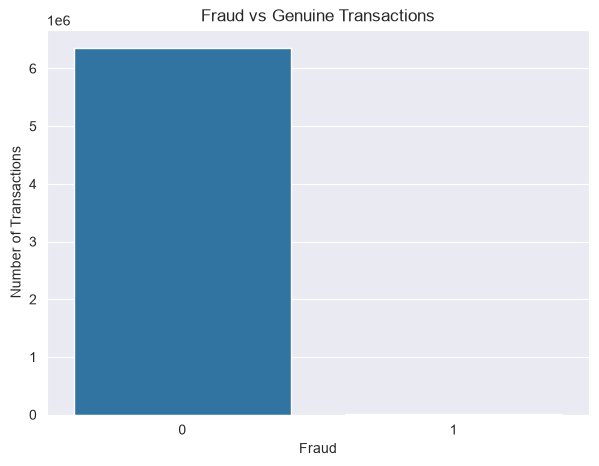

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Fraud")
plt.ylabel("Number of Transactions")

plt.show()

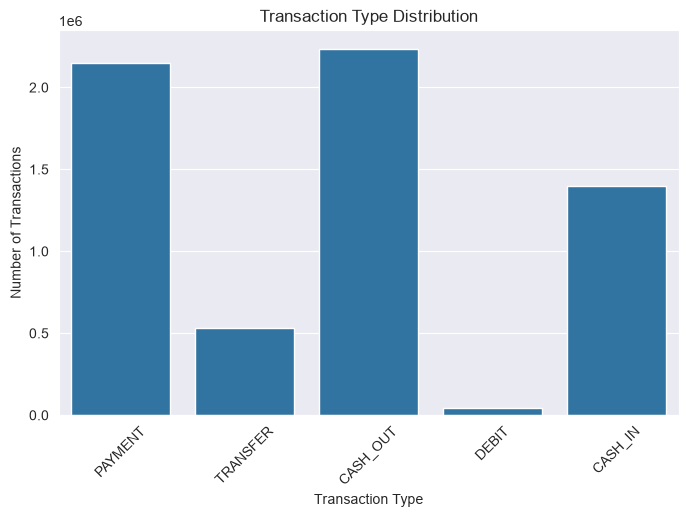

In [12]:
df["type"].value_counts()
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type"
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

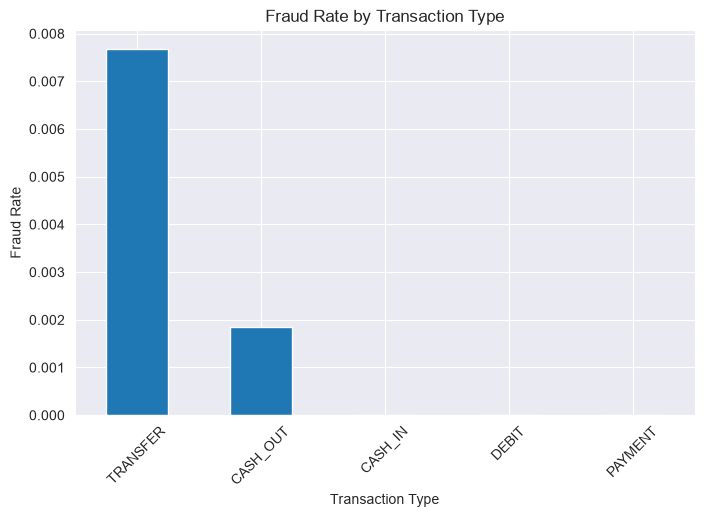

In [13]:
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .sort_values(ascending=False)
)

fraud_rate_by_type

plt.figure(figsize=(8, 5))

fraud_rate_by_type.plot(
    kind="bar"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=45)

plt.show()

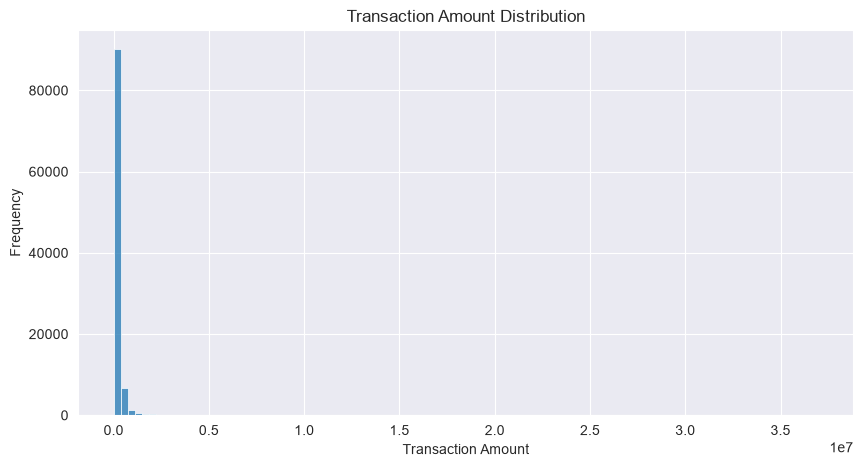

In [14]:
amount_sample = df["amount"].sample(
    n=min(100000, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 5))

sns.histplot(
    amount_sample,
    bins=100
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [17]:
fraud_df = df[df["isFraud"] == 1]
fraud_df["amount"].describe()

count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64

In [18]:
genuine_df = df[df["isFraud"] == 0]
genuine_df["amount"].describe()

count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64

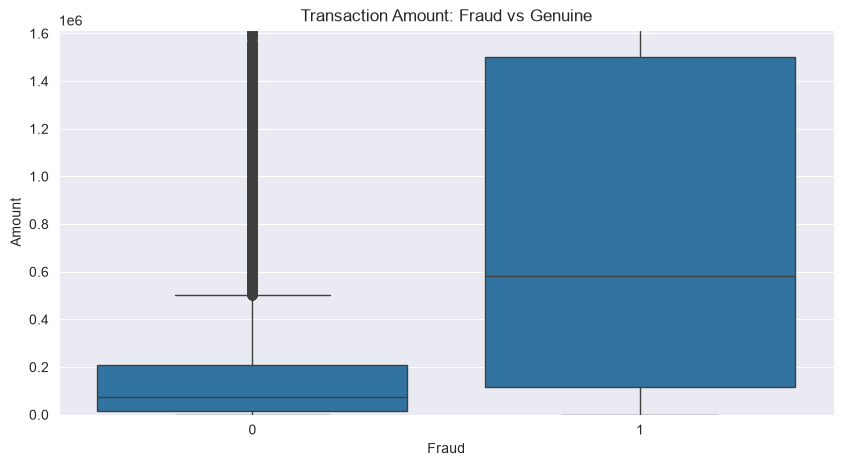

In [19]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df.sample(
        n=min(100000, len(df)),
        random_state=42
    ),
    x="isFraud",
    y="amount"
)

plt.title("Transaction Amount: Fraud vs Genuine")
plt.xlabel("Fraud")
plt.ylabel("Amount")

plt.ylim(
    0,
    df["amount"].quantile(0.99)
)

plt.show()

In [20]:
balance_columns = [
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]
df[balance_columns].describe()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06
std,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05
75%,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06
max,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08


In [21]:
numeric_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFraud",
    "isFlaggedFraud"
]

correlation = df[numeric_columns].corr()

correlation

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578,0.003277
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.003277,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


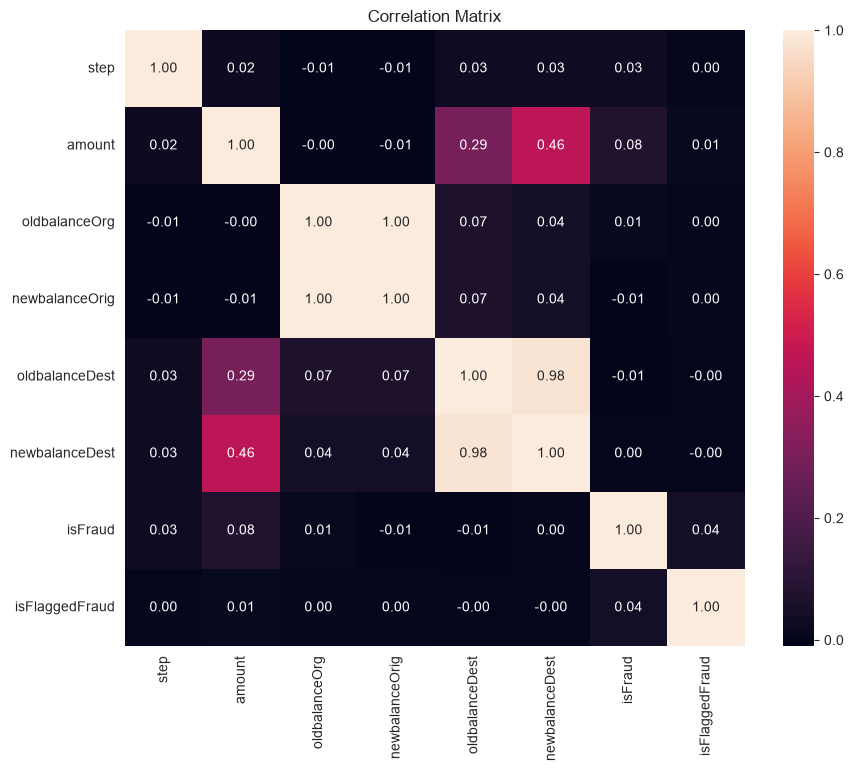

In [22]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## EDA Conclusions

1. The dataset contains a highly imbalanced fraud classification problem.
2. Fraudulent transactions represent only a very small proportion of total transactions.
3. Transaction type shows different fraud patterns.
4. Transaction amount and balance-related features provide useful information for fraud detection.
5. The severe class imbalance means accuracy alone is not sufficient for evaluating the model.
6. SMOTE and class-weight balancing will therefore be considered during model training.